Name: Tanvi Gajanan Upganlawar

Roll no: 12

PRN no: 1252090012

---



ASSIGNMENT5

Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks: 1. Pre-process the dataset. 2. Identify outliers. 3. Check the correlation. 4. Implement linear regression and ridge, Lasso regression models. 5. Evaluate the models and compare their respective scores like R2, RMSE, etc. Dataset link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("uber.csv")

In [ ]:
df.shape

(200000, 9)

In [ ]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


**Pre process the data**

check missing values

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


drop missing values

In [ ]:
df.dropna(inplace=True)


convert datetime

In [ ]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

remove invalid values

In [ ]:
df = df[
    (df["fare_amount"] > 0) &
    (df["pickup_latitude"].between(-90, 90)) &
    (df["dropoff_latitude"].between(-90, 90)) &
    (df["pickup_longitude"].between(-180, 180)) &
    (df["dropoff_longitude"].between(-180, 180))
]


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


**Data transformation**

remove unnecessary columns

In [ ]:
df.drop(columns=["Unnamed: 0", "key"], inplace=True)

**Outliers**

In [ ]:
Q1 = df["fare_amount"].quantile(0.25)
Q3 = df["fare_amount"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["fare_amount"] >= Q1 - 1.5*IQR) &
        (df["fare_amount"] <= Q3 + 1.5*IQR)]




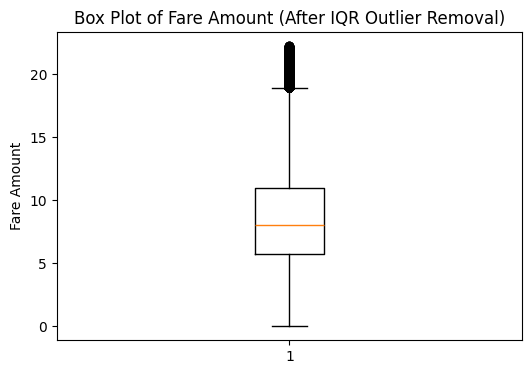

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["fare_amount"])
plt.title("Box Plot of Fare Amount (After IQR Outlier Removal)")
plt.ylabel("Fare Amount")
plt.show()


**Correlation Analysis**

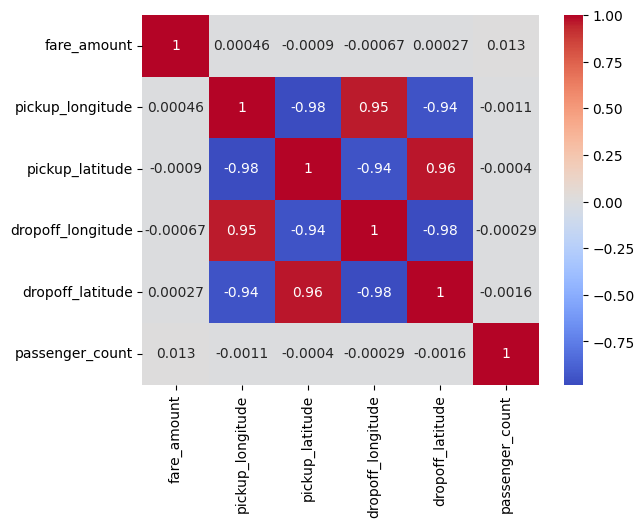

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["fare_amount","pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude","passenger_count"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


check the correlation

In [ ]:
df.corr(method='pearson')

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
fare_amount,1.000000,0.140420,0.000464,-0.000902,-0.000669,0.000265,0.012625
pickup_datetime,0.140420,1.000000,0.009158,-0.011232,0.008848,-0.010898,0.003942
pickup_longitude,0.000464,0.009158,1.000000,-0.980257,0.954735,-0.942702,-0.001069
pickup_latitude,-0.000902,-0.011232,-0.980257,1.000000,-0.942419,0.962277,-0.000396
dropoff_longitude,-0.000669,0.008848,0.954735,-0.942419,1.000000,-0.980800,-0.000292
dropoff_latitude,0.000265,-0.010898,-0.942702,0.962277,-0.980800,1.000000,-0.001586
passenger_count,0.012625,0.003942,-0.001069,-0.000396,-0.000292,-0.001586,1.000000


In [ ]:
df.corr(method='spearman')

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
fare_amount,1.000000,0.142110,-0.046392,-0.070600,0.022347,-0.073346,0.020793
pickup_datetime,0.142110,1.000000,-0.001013,-0.005053,0.001173,-0.001100,-0.013558
pickup_longitude,-0.046392,-0.001013,1.000000,0.573033,0.457148,0.278491,-0.020491
pickup_latitude,-0.070600,-0.005053,0.573033,1.000000,0.252481,0.563163,-0.015135
dropoff_longitude,0.022347,0.001173,0.457148,0.252481,1.000000,0.520189,-0.017505
dropoff_latitude,-0.073346,-0.001100,0.278491,0.563163,0.520189,1.000000,-0.010072
passenger_count,0.020793,-0.013558,-0.020491,-0.015135,-0.017505,-0.010072,1.000000


In [ ]:
df.corr(method='kendall')

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
fare_amount,1.000000,0.095982,-0.031948,-0.048203,0.014479,-0.049951,0.016297
pickup_datetime,0.095982,1.000000,-0.000668,-0.003356,0.000785,-0.000732,-0.010449
pickup_longitude,-0.031948,-0.000668,1.000000,0.433804,0.321524,0.195623,-0.015906
pickup_latitude,-0.048203,-0.003356,0.433804,1.000000,0.178329,0.404498,-0.011742
dropoff_longitude,0.014479,0.000785,0.321524,0.178329,1.000000,0.399575,-0.013557
dropoff_latitude,-0.049951,-0.000732,0.195623,0.404498,0.399575,1.000000,-0.007811
passenger_count,0.016297,-0.010449,-0.015906,-0.011742,-0.013557,-0.007811,1.000000


**Linear, ridge, and lasso regression**

linear regression

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
df = pd.DataFrame({
    'Hours_Studied': [2, 4, 6],
    'Marks': [50, 55, 65]
})

X = df[['Hours_Studied']]
y = df['Marks']

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

df['Predicted_Marks'] = model.predict(X)

print("Slope (b1):", slope)
print("Intercept (b0):", intercept)
df

Slope (b1): 3.7499999999999987
Intercept (b0): 41.66666666666667


,Hours_Studied,Marks,Predicted_Marks
0,2,50,49.166667
1,4,55,56.666667
2,6,65,64.166667


/tmp/ipython-input-1444297466.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


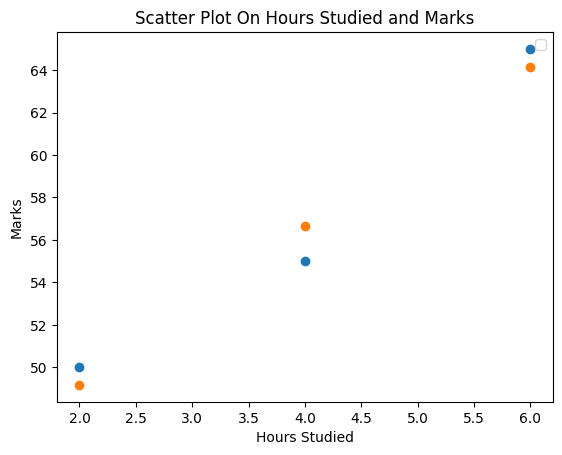

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours_Studied'], df['Marks'])
plt.scatter(df['Hours_Studied'], df['Predicted_Marks'])

plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Scatter Plot On Hours Studied and Marks')
plt.legend()
plt.show()

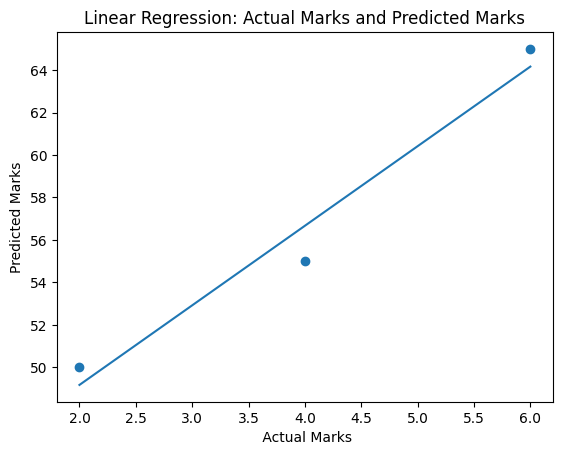

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours_Studied'], df['Marks'])
plt.plot(df['Hours_Studied'], df['Predicted_Marks'])
plt.xlabel(" Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Linear Regression: Actual Marks and Predicted Marks")
plt.show()


Calculate mse and r^2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(df['Marks'], df['Predicted_Marks'])
r2 = r2_score(df['Marks'], df['Predicted_Marks'])
print("MSE:", mse)
print("R² Score:", r2)

MSE: 1.3888888888888886
R² Score: 0.9642857142857143


Linear regression (rainfall and yeild)

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.DataFrame({
    'Rainfall': [12.3, 13.7, 14.5, 11.2, 13.2, 14.1, 12.0],
    'Yield': [6.25, 8.02, 8.42, 5.27, 7.21, 8.71, 5.68]
})

X = df[['Rainfall']]
y = df['Yield']

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

df['Predicted_Yield'] = model.predict(X)

print("Slope (b1):", slope)
print("Intercept (b0):", intercept)
df


Slope (b1): 1.1153669724770645
Intercept (b0): -7.419770642201839


,Rainfall,Yield,Predicted_Yield
0,12.3,6.25,6.299243
1,13.7,8.02,7.860757
2,14.5,8.42,8.753050
3,11.2,5.27,5.072339
4,13.2,7.21,7.303073
5,14.1,8.71,8.306904
6,12.0,5.68,5.964633


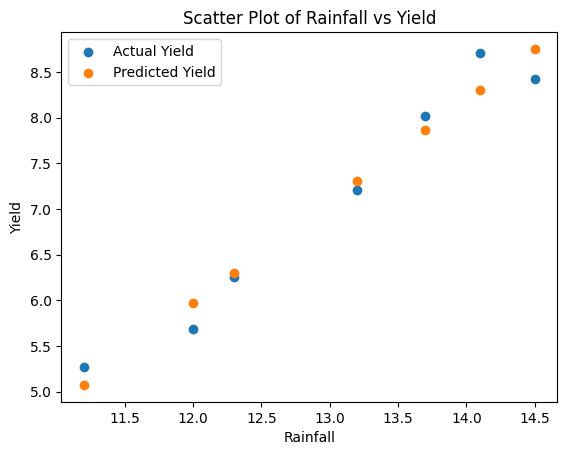

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Rainfall'], df['Yield'], label='Actual Yield')
plt.scatter(df['Rainfall'], df['Predicted_Yield'], label='Predicted Yield')

plt.xlabel('Rainfall')
plt.ylabel('Yield')
plt.title('Scatter Plot of Rainfall vs Yield')
plt.legend()
plt.show()

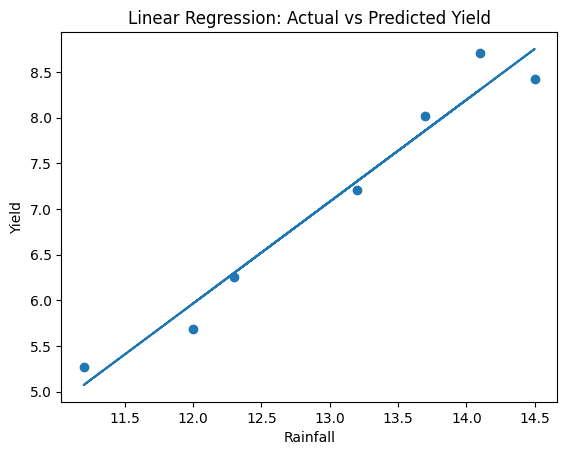

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Rainfall'], df['Yield'])
plt.plot(df['Rainfall'], df['Predicted_Yield'])

plt.xlabel('Rainfall')
plt.ylabel('Yield')
plt.title("Linear Regression: Actual vs Predicted Yield")
plt.show()

Calculate mse and r^2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(df['Yield'], df['Predicted_Yield'])
r2 = r2_score(df['Yield'], df['Predicted_Yield'])
print("MSE:", mse)
print("R² Score:", r2)

MSE: 0.06142011795543894
R² Score: 0.9618779193395928


**Logistic regression**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

actual = [1,0,0,1,0,0,1,0,0,1]
predicted = [1,0,0,1,0,0,0,1,0,0]

cm = confusion_matrix(actual, predicted)
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()
print("\nTrue Positive (TP):", tp)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Negative (TN):", tn)

print("\nClassification Report:\n")
print(classification_report(actual, predicted))

Confusion Matrix:
 [[5 1]
 [2 2]]

True Positive (TP): 2
False Positive (FP): 1
False Negative (FN): 2
True Negative (TN): 5

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.67      0.50      0.57         4

    accuracy                           0.70        10
   macro avg       0.69      0.67      0.67        10
weighted avg       0.70      0.70      0.69        10

